In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa
from pypower.loadcase import loadcase
from scipy.io import loadmat
from pymatreader import read_mat

from pathlib import Path
import os
import sys

sys.path.append("../utils")
from matpower_io import load_matpower_case

import matplotlib.pyplot as plt
import cartopy.crs as ccrs


In [2]:
tamu_path = Path("../../../2021TXPowerOutage")
os.listdir(tamu_path/"bte2k")

['case_Mar3_5pm.mat', 'design3.mat', 'hvdc_upgraded.mat']

In [3]:
ppc, extras = load_matpower_case(tamu_path/"bte2k/case_Mar3_5pm.mat")

In [4]:
extras.keys()

dict_keys(['zone', 'sub', 'subid', 'busid', 'bus2sub', 'genid', 'genfuel', 'genfuelcost', 'heatratecurve', 'branchid', 'branchdevicetype'])

In [5]:
n = pypsa.Network() 
n.import_from_pypower_ppc(ppc, overwrite_zero_s_nom=1e6)
n.generators['carrier'] = extras['genfuel']

In [6]:
n

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 2000
 - Generator: 606
 - Line: 2359
 - Load: 1125
 - ShuntImpedance: 150
 - Transformer: 847
Snapshots: 1

In [7]:
mpc_dict = read_mat(tamu_path/"bte2k/case_Mar3_5pm.mat")['mpc']

In [8]:
mpc_dict.keys()

dict_keys(['version', 'baseMVA', 'zone', 'sub', 'subid', 'bus', 'busid', 'bus2sub', 'gen', 'genid', 'genfuel', 'genfuelcost', 'heatratecurve', 'branch', 'branchid', 'branchdevicetype', 'gencost'])

In [9]:
bus2sub = pd.DataFrame(mpc_dict['bus2sub'], columns=['subid','state'])
bus2sub['busid'] = mpc_dict['busid']

In [10]:
sub_geo = pd.DataFrame(mpc_dict['sub'], columns=['name','idx','y','x','state'])

In [11]:
sub_geo['subid'] = mpc_dict['subid']

In [12]:
bus_geo = pd.merge(sub_geo, bus2sub, on=['state','subid'])

In [13]:
bus_geo = bus_geo.set_index(['busid'])
bus_geo.index.name = 'name'

In [14]:
n.buses[['x','y']] = bus_geo[['x','y']].values

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x255aa973390>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x255aa9734d0>,
  'Transformer': <matplotlib.collections.LineCollection at 0x255aa973610>},
 'flows': {}}

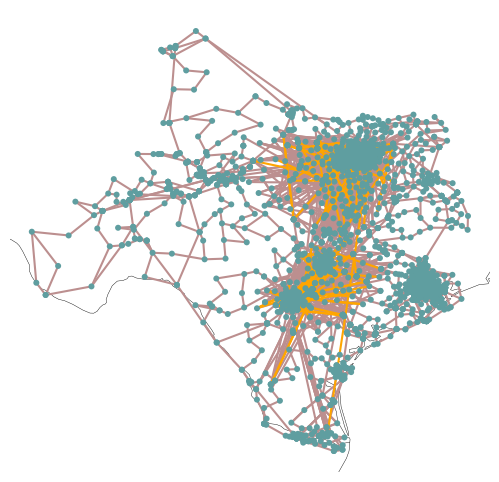

In [22]:
fig, ax = plt.subplots(figsize=(8,6),subplot_kw={'projection': ccrs.PlateCarree()})
n.plot(ax=ax, bus_size=0.005)